<a href="https://www.kaggle.com/code/taraskin5201/hw2-3-dataset?scriptVersionId=294149780" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [4]:
import os

Ознайомитись з даними та структурою даних

In [5]:
data_dir = '/kaggle/input/fruit-recognition/train/train'

# Перевіряємо класи
classes = os.listdir(data_dir)
print("Класи:", classes)

# Кількість зображень у кожному класі
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    num_images = len(os.listdir(cls_path))
    print(f"{cls}: {num_images} зображень")

Класи: ['Orange', 'Tomato', 'Passion Fruit', 'Cucumber Ripe', 'Cactus fruit', 'Pomegranate', 'Plum', 'Pineapple', 'Papaya', 'Potato Red', 'Kiwi', 'Limes', 'Apple Braeburn', 'Pear', 'Onion White', 'Strawberry', 'Grape Blue', 'Blueberry', 'Apple Granny Smith', 'Apricot', 'Pepper Red', 'Clementine', 'Lemon', 'Avocado', 'Raspberry', 'Cantaloupe', 'Peach', 'Corn', 'Banana', 'Cherry', 'Pepper Green', 'Watermelon', 'Mango']
Orange: 479 зображень
Tomato: 738 зображень
Passion Fruit: 490 зображень
Cucumber Ripe: 392 зображень
Cactus fruit: 490 зображень
Pomegranate: 492 зображень
Plum: 447 зображень
Pineapple: 490 зображень
Papaya: 492 зображень
Potato Red: 450 зображень
Kiwi: 466 зображень
Limes: 490 зображень
Apple Braeburn: 492 зображень
Pear: 696 зображень
Onion White: 438 зображень
Strawberry: 492 зображень
Grape Blue: 984 зображень
Blueberry: 462 зображень
Apple Granny Smith: 492 зображень
Apricot: 492 зображень
Pepper Red: 666 зображень
Clementine: 490 зображень
Lemon: 492 зображень
Avoc

Створіть доповнення(transform) для тренувальних та тестових даних.

In [6]:
from torchvision import transforms

# Трансформації для тренувальних даних 
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),  # змінюємо розмір
    transforms.ToTensor()           # перетворюємо у тензор
])

# Трансформації для тестових даних
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])


Створіть train_dataset та test_dataset за допомогою ImageFolder(папка train)

In [7]:
import torch
from torch.utils.data import random_split
from torchvision import datasets

In [8]:
data_dir = '/kaggle/input/fruit-recognition/train/train'

# Створюємо загальний dataset
dataset = datasets.ImageFolder(
    root=data_dir,
    transform=train_transform
)

# Перевіримо класи
print("Класи:", dataset.classes)
print("Загальна кількість зображень:", len(dataset))


Класи: ['Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Banana', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Cherry', 'Clementine', 'Corn', 'Cucumber Ripe', 'Grape Blue', 'Kiwi', 'Lemon', 'Limes', 'Mango', 'Onion White', 'Orange', 'Papaya', 'Passion Fruit', 'Peach', 'Pear', 'Pepper Green', 'Pepper Red', 'Pineapple', 'Plum', 'Pomegranate', 'Potato Red', 'Raspberry', 'Strawberry', 'Tomato', 'Watermelon']
Загальна кількість зображень: 16854


In [9]:
# Визначаємо розміри
total_size = len(dataset)
train_size = int(0.8 * total_size)  # 80% для тренування
test_size = total_size - train_size # 20% для тесту

# Розділяємо dataset
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")


Train size: 13483, Test size: 3371


Переконайтесь що у вас привильні назви класів

In [10]:
print("Назви класів у train_dataset:", dataset.classes)
print("Назви класів у test_dataset:", dataset.classes)


Назви класів у train_dataset: ['Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Banana', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Cherry', 'Clementine', 'Corn', 'Cucumber Ripe', 'Grape Blue', 'Kiwi', 'Lemon', 'Limes', 'Mango', 'Onion White', 'Orange', 'Papaya', 'Passion Fruit', 'Peach', 'Pear', 'Pepper Green', 'Pepper Red', 'Pineapple', 'Plum', 'Pomegranate', 'Potato Red', 'Raspberry', 'Strawberry', 'Tomato', 'Watermelon']
Назви класів у test_dataset: ['Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Banana', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Cherry', 'Clementine', 'Corn', 'Cucumber Ripe', 'Grape Blue', 'Kiwi', 'Lemon', 'Limes', 'Mango', 'Onion White', 'Orange', 'Papaya', 'Passion Fruit', 'Peach', 'Pear', 'Pepper Green', 'Pepper Red', 'Pineapple', 'Plum', 'Pomegranate', 'Potato Red', 'Raspberry', 'Strawberry', 'Tomato', 'Watermelon']


Створіть DataLoader для тренувальних та тестових даних

In [11]:
from torch.utils.data import DataLoader


In [12]:
# Параметри
batch_size = 32  

# DataLoader для тренувальних даних
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# DataLoader для тестових даних
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


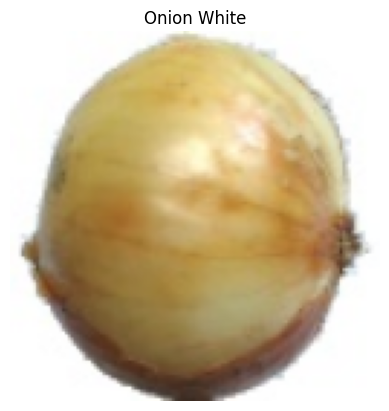

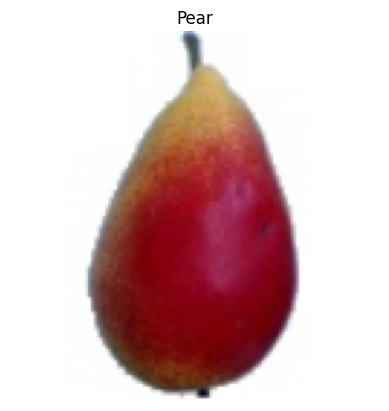

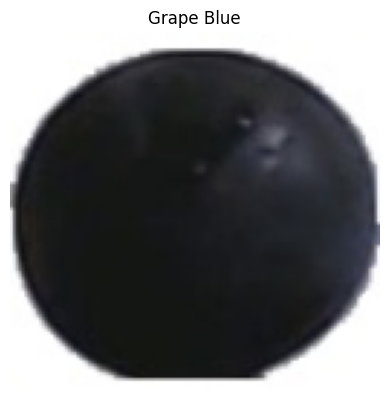

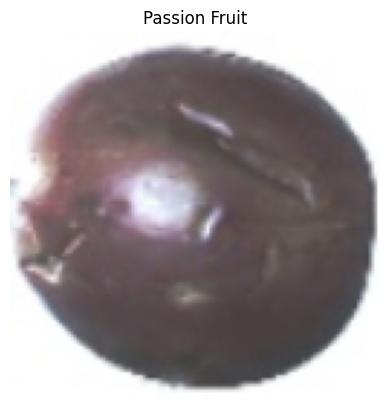

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img, title):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')
    plt.show()


dataiter = iter(train_loader)
images, labels = next(dataiter)

for i in range(4):
    imshow(images[i], title=dataset.classes[labels[i]])



На основі train_dataset та test_dataset з попереднього завдання створити train_loader та test_loader

In [14]:

batch_size = 32

# DataLoader для тренувальних даних
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# DataLoader для тестових даних
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Перевіримо кількість батчів
print(f"Кількість батчів у train_loader: {len(train_loader)}")
print(f"Кількість батчів у test_loader: {len(test_loader)}")


Кількість батчів у train_loader: 422
Кількість батчів у test_loader: 106


Створити нейромережу:

використайте 3-5 шари

перший шар Flatten

кількість нейронів у шарах має не збільшуватись

використайте функції активації RELU або LeakyRELU

In [15]:
import torch.nn as nn

In [16]:
model = nn.Sequential(
    nn.Flatten(),                
    nn.Linear(128*128*3, 1024), 
    nn.ReLU(),
    nn.Linear(1024, 512),       
    nn.ReLU(),
    nn.Linear(512, 256),        
    nn.ReLU(),
    nn.Linear(256, 33)          
)


In [17]:
import torch
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print("Device:", device)

Device: cpu


In [18]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


In [20]:
loss_list = []
loss_test_list = []

for i in range(3):
    print(f"\nEpoch {i+1}")

    # ===== TRAIN =====
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        result = model(imgs)
        loss = loss_fn(result, labels)
        print(f"train loss: {loss.item()}")

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_list.append(loss.cpu().item())

    # ===== TEST =====
    with torch.no_grad():   
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            result = model(imgs)
            loss = loss_fn(result, labels)
            print(f"test loss: {loss.item()}")

            loss_test_list.append(loss.cpu().item())


Epoch 1
train loss: 1.4285849332809448
train loss: 1.46025812625885
train loss: 1.7984780073165894
train loss: 1.896467924118042
train loss: 1.3470425605773926
train loss: 0.9335271716117859
train loss: 1.480542540550232
train loss: 1.1530579328536987
train loss: 1.2081987857818604
train loss: 1.1285609006881714
train loss: 1.251402735710144
train loss: 0.9874195456504822
train loss: 1.0621088743209839
train loss: 0.9662697315216064
train loss: 1.2882426977157593
train loss: 1.2180665731430054
train loss: 1.4661810398101807
train loss: 0.9521504640579224
train loss: 1.3097680807113647
train loss: 1.2127255201339722
train loss: 1.2106643915176392
train loss: 1.09989595413208
train loss: 0.8515549302101135
train loss: 0.9350160956382751
train loss: 0.578486979007721
train loss: 1.1350953578948975
train loss: 0.8504359126091003
train loss: 0.8495011329650879
train loss: 0.6940686702728271
train loss: 1.1319361925125122
train loss: 1.065865159034729
train loss: 0.7770549058914185
train lo

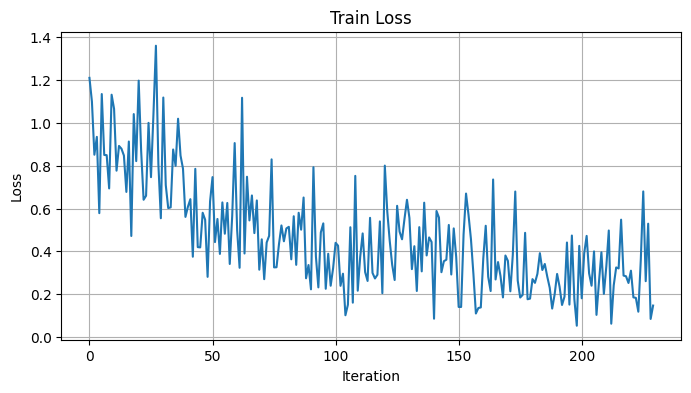

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(loss_list[20:250])
plt.title("Train Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.show()


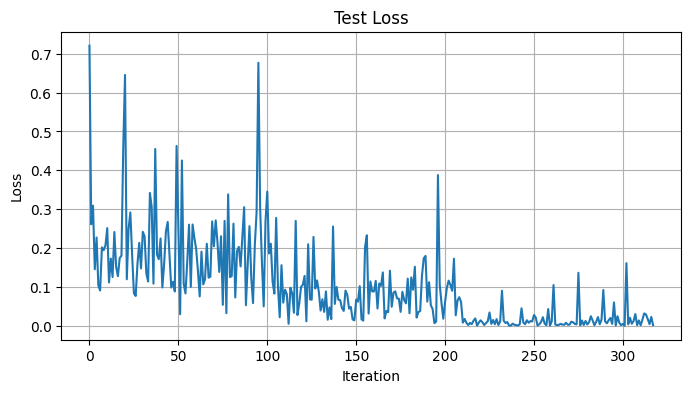

In [35]:
plt.figure(figsize=(8, 4))
plt.plot(loss_test_list)
plt.title("Test Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.show()
